# Entregável 3 — Sistema Multiagente

> **Grupo:** Mariana Aparecida Ferreira, Vinicius Luis Belem Bronzatti
> **Tema/Projeto:** RiskOps — Sistema Multiagente para Gestão Automatizada do Ciclo de Vida de Regras de Risco

Este notebook transforma a v2 (Entregável 2, um único agente + ferramenta) em um sistema com
dois agentes de responsabilidades distintas: diagnóstico (herdado da v2) e geração de regras
candidatas (novo).


# A. Estrutura herdada do Entregável 2

Pacote `riskops` (schema/registro de regras, avaliador, métricas de backtest,
`riskops.diagnostics` -- lógica do baseline, reaproveitada sem alteração -- e
`riskops.portfolio_graph` -- o grafo da v2, trazido aqui **executável**, pois será reexecutado
nesta entrega, Seção F), a amostra do BAF, o registro de regras, o conjunto de casos congelado
`test_cases` (T01-T10, idêntico ao E1/E2) e o `RUN_INFO`.

A v2 será **reexecutada nesta entrega**, com o mesmo modelo e mesmo ambiente da v3 (Seção F) --
mesma disciplina metodológica do E1→E2 (não reaproveitamos números de uma entrega anterior;
trocar o modelo entre as versões impediria atribuir a diferença observada à arquitetura).

**Mudança de provedor de LLM nesta entrega (Groq → Anthropic), com evidência real do motivo:**
o modelo usado em E1/E2 (`openai/gpt-oss-20b` via Groq, plano gratuito) tem uma cota diária de
200 mil tokens que se mostrou, na prática, impossível de completar esta entrega -- entre
tentativas de execução real ao longo de dois dias, a cota chegou a 199.878/200.000 tokens
usados, com erros 429 reais capturados (`"Rate limit reached ... on tokens per day (TPD)"`).
Trocamos para a Anthropic (`claude-haiku-4-5-20251001`) para conseguir terminar a entrega no
prazo. A disciplina de **não trocar de modelo entre v2 e v3 dentro desta mesma entrega** continua
valendo à risca -- as duas usam o mesmo `llm` (Seção A, célula de configuração) -- só o provedor
usado por ambas mudou em relação a entregas anteriores, e essa mudança está documentada aqui,
não escondida.

**Release do GitHub referente a este entregável:** `entregavel-3` (ver Seção 2.2 do enunciado --
requisito novo em relação a E1/E2 para grupos que desenvolvem em repositório).

**Como executar cada etapa a partir do código do repositório** (Seção 2.2 do enunciado): este
notebook não reimplementa nada inline -- toda lógica vem do pacote `riskops`, clonado do
repositório acima. Para reproduzir cada etapa fora do notebook, os pontos de entrada são:

- **Agente 1 isolado (diagnóstico de uma regra):**
  `riskops.diagnostics.diagnosticar_regra(rule_id, store=store, df=df, structured_llm=structured_llm_diagnostico)`.
- **v2 completa (um único agente, fila de regras):**
  `riskops.portfolio_graph.build_graph(store=store, df=df, llm=llm, structured_llm=structured_llm_diagnostico).compile().invoke({"fila_regras": [...], ...})`.
- **v3 completa (dois agentes, diagnóstico + gerador):**
  `riskops.multiagent_graph.build_graph(store=store, df=df, llm=llm, structured_llm_diagnostico=structured_llm_diagnostico, structured_llm_gerador=structured_llm_gerador).compile().invoke({"fila_regras": [...], ...})`.
- **Agente 2 isolado (gerar e testar uma candidata, sem LLM):**
  `riskops.rule_generator.construir_regra_candidata(...)` seguido de
  `riskops.rule_generator.avaliar_candidata(df, regra_atual, candidata)`.
- **Toda a suíte de testes (com LLMs falsos, sem precisar de chave de API):**
  `poetry run pytest`, a partir da raiz do repositório clonado.


In [1]:
!git clone --quiet --depth 1 https://github.com/bronzattivinicius/riskops.git riskops_repo
%pip install -q -U langchain-anthropic pydantic pandas >/dev/null


Note: you may need to restart the kernel to use updated packages.


In [2]:
# O pacote riskops eh Python puro, entao apontamos o interpretador direto para o
# codigo-fonte clonado -- evita a necessidade de reiniciar o kernel apos uma instalacao
# editavel via pip (ver Entregavel 1, Secao 11, para o motivo).
import sys

sys.path.insert(0, "riskops_repo/src")

import riskops

print("riskops importado de:", riskops.__file__)


riskops importado de: /Users/viniciusbronzatti/Downloads/riskops/riskops_repo/src/riskops/__init__.py


In [3]:
import os, getpass, datetime, platform

os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGSMITH_TRACING"] = "false"

def carregar_chave_anthropic() -> str:
    """Carrega a ANTHROPIC_API_KEY sem jamais escreve-la neste notebook."""
    if os.environ.get("ANTHROPIC_API_KEY"):
        return "variavel de ambiente"
    try:
        from google.colab import userdata          # noqa: F401
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("INF0093-2026-2S-ANTHROPIC")
        return "Colab userdata"
    except Exception:
        os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("ANTHROPIC_API_KEY: ")
        return "entrada manual"

origem = carregar_chave_anthropic()
assert os.environ.get("ANTHROPIC_API_KEY"), "Chave nao configurada."
print("Chave carregada via:", origem)


Chave carregada via: variavel de ambiente


In [4]:
from langchain_anthropic import ChatAnthropic
from riskops.diagnostics import RuleAssessment
from riskops.rule_generator import RegraCandidataFinal

# Provedor trocado de Groq para Anthropic nesta entrega -- ver justificativa na Secao A.
MODEL_NAME = "claude-haiku-4-5-20251001"
TEMPERATURE = 0
PROMPT_VERSAO_DIAGNOSTICO = "v1"           # prompt do diagnostico de uma regra, inalterado desde o E1
PROMPT_VERSAO_AGENTE_DIAGNOSTICO = "v2-agente-v1"  # instrucao de sistema do agente de diagnostico, inalterada desde o E2
PROMPT_VERSAO_AGENTE_GERADOR = "v3-gerador-v1"     # nova instrucao de sistema do agente gerador (Secao C)

llm = ChatAnthropic(model=MODEL_NAME, temperature=TEMPERATURE, max_retries=8, timeout=60, max_tokens=1024)
structured_llm_diagnostico = llm.with_structured_output(RuleAssessment, include_raw=True)
structured_llm_gerador = llm.with_structured_output(RegraCandidataFinal, include_raw=True)

RUN_INFO = {
    "provedor": "anthropic",
    "modelo": MODEL_NAME,
    "temperatura": TEMPERATURE,
    "prompt_versao_diagnostico": PROMPT_VERSAO_DIAGNOSTICO,
    "prompt_versao_agente_diagnostico": PROMPT_VERSAO_AGENTE_DIAGNOSTICO,
    "prompt_versao_agente_gerador": PROMPT_VERSAO_AGENTE_GERADOR,
    "data": datetime.datetime.now().isoformat(timespec="seconds"),
    "python": platform.python_version(),
}
RUN_INFO


{'provedor': 'anthropic',
 'modelo': 'claude-haiku-4-5-20251001',
 'temperatura': 0,
 'prompt_versao_diagnostico': 'v1',
 'prompt_versao_agente_diagnostico': 'v2-agente-v1',
 'prompt_versao_agente_gerador': 'v3-gerador-v1',
 'data': '2026-09-20T20:54:11',
 'python': '3.12.14'}

In [5]:
import re
import time
import concurrent.futures
from anthropic import APIError

_EXECUTOR = concurrent.futures.ThreadPoolExecutor(max_workers=8)

class TravamentoDeRede(Exception):
    pass

def _com_timeout_forcado(chamada, segundos=90):
    """Mata a chamada apos `segundos`, nao importa o que aconteca por dentro.

    O `timeout` do proprio cliente as vezes nao basta -- um travamento de
    rede real foi observado ao executar esta entrega, durando minutos sem
    nenhuma excecao ser levantada. Isolar em thread e usar
    `future.result(timeout=...)` garante um limite superior duro.
    """
    future = _EXECUTOR.submit(chamada)
    try:
        return future.result(timeout=segundos)
    except concurrent.futures.TimeoutError:
        raise TravamentoDeRede(f"chamada nao respondeu em {segundos}s (travamento de rede)")

def invocar_com_retry(chamada, max_tentativas=6):
    """Chama `chamada()` (sem argumentos), retentando em erros transientes.

    Cobre rate limit, timeout e erro de conexao (`anthropic.APIError` e
    suas subclasses), mais um timeout forcado por fora contra travamentos
    de rede que nao levantam excecao alguma -- ambos observados de verdade
    ao executar esta entrega (Secao G).
    """
    for tentativa in range(1, max_tentativas + 1):
        try:
            return _com_timeout_forcado(chamada)
        except TravamentoDeRede as exc:
            espera = 20
            print(f"{exc} (tentativa {tentativa}/{max_tentativas}) -- aguardando {espera}s...")
            if tentativa == max_tentativas:
                raise
            time.sleep(espera)
        except APIError as exc:
            match = re.search(r"try again in (?:(\d+)m)?([\d.]+)s", str(exc))
            espera = (int(match.group(1) or 0) * 60 + float(match.group(2)) + 5) if match else 30
            print(f"Erro transiente ({type(exc).__name__}, tentativa {tentativa}/{max_tentativas}) -- aguardando {espera:.0f}s...")
            if tentativa == max_tentativas:
                raise
            time.sleep(espera)


**Checkpoint de progresso (decisão de resiliência, motivada por uma limitação real observada ao executar esta entrega):** a cota diária do Groq (200 mil tokens) se mostrou, na prática, insuficiente para rodar a Seção F (os 10 casos em duas versões) numa única sessão contínua sem interrupções -- um novo modo de falha que a v2 nunca expôs com essa gravidade. Em vez de reexecutar tudo do zero a cada interrupção, cada caso já computado é salvo em `v3_progress.json` assim que termina; uma nova execução carrega esse arquivo e pula direto para o que falta.


In [6]:
import json
from pathlib import Path

PROGRESS_PATH = Path("v3_progress.json")

def carregar_progresso():
    """Carrega o checkpoint de progresso salvo, se existir.

    Guardado fora do clone efemero (riskops_repo/), entao sobrevive a uma
    nova clonagem. Existe porque a cota diaria do Groq (200k tokens) se
    mostrou, na pratica, dificil de esgotar numa unica sessao continua --
    uma execucao interrompida no meio do caminho nao deveria ter que
    refazer chamadas ja gastas com sucesso quando a execucao for retomada
    (novo modo de falha real, documentado na Secao G).
    """
    if PROGRESS_PATH.exists():
        with open(PROGRESS_PATH, encoding="utf-8") as f:
            return json.load(f)
    return {"v2": {}, "v3": {}}

def salvar_progresso(progresso):
    with open(PROGRESS_PATH, "w", encoding="utf-8") as f:
        json.dump(progresso, f, ensure_ascii=False, indent=2, default=str)

progresso = carregar_progresso()
print(f"Checkpoint carregado: {len(progresso['v2'])} casos v2, {len(progresso['v3'])} casos v3 ja computados.")


Checkpoint carregado: 10 casos v2, 10 casos v3 ja computados.


In [7]:
from pathlib import Path
from riskops.data.loader import load_baf
from riskops.rules.store import RuleStore

REPO_DIR = Path("riskops_repo")
df = load_baf(path=REPO_DIR / "data" / "sample" / "baf_sample.csv")
store = RuleStore(root=REPO_DIR / "rule_registry")

print(f"{len(df)} transacoes carregadas | taxa de fraude na amostra: {df['fraud_bool'].mean():.2%}")
print(f"{len(store.list_rule_ids())} regras no registro: {store.list_rule_ids()}")


20000 transacoes carregadas | taxa de fraude na amostra: 1.10%
8 regras no registro: ['baf_device_email_reuse', 'baf_foreign_request', 'baf_free_email_domain', 'baf_high_credit_risk_score', 'baf_high_velocity_6h', 'baf_impossible_threshold', 'baf_invalid_phone_combo', 'baf_weak_identity_match_elevated_risk']


Conjunto de casos congelado, **idêntico ao E1/E2** (T01-T10; nenhum caso foi modificado ou
removido). A célula abaixo prova isso comparando, ao vivo, a impressão digital deste conjunto
com a do conjunto usado no E2.


In [8]:
test_cases = [
    {"id": "T01", "rule_id": "baf_foreign_request", "tipo": "normal", "verificacao": "auto"},
    {"id": "T02", "rule_id": "baf_free_email_domain", "tipo": "normal", "verificacao": "auto"},
    {"id": "T03", "rule_id": "baf_high_velocity_6h", "tipo": "normal", "verificacao": "auto"},
    {"id": "T04", "rule_id": "baf_high_credit_risk_score", "tipo": "normal", "verificacao": "auto"},
    {"id": "T05", "rule_id": "baf_weak_identity_match_elevated_risk", "tipo": "normal", "verificacao": "auto"},
    {"id": "T06", "rule_id": "baf_device_email_reuse", "tipo": "normal", "verificacao": "auto"},
    {"id": "T07", "rule_id": "baf_invalid_phone_combo", "tipo": "ambiguo", "verificacao": "manual"},
    {"id": "T08", "rule_id": "baf_impossible_threshold", "tipo": "zero-match", "verificacao": "auto"},
    {"id": "T09", "rule_id": "regra_fantasma", "tipo": "informacao ausente", "verificacao": "auto"},
    {"id": "T10", "rule_id": "", "tipo": "entrada incompleta", "verificacao": "auto"},
]

from riskops.diagnostics import impressao_digital_casos

fingerprint_e3 = impressao_digital_casos(test_cases)
print(len(test_cases), "casos definidos.")
print("impressao digital do conjunto (E3):", fingerprint_e3)

import json as _json

with open(REPO_DIR / "E2_Ferreira_Bronzatti.ipynb", encoding="utf-8") as _f:
    _nb_e2 = _json.load(_f)
_src_e2 = next("".join(c["source"]) for c in _nb_e2["cells"] if "test_cases = [" in "".join(c["source"]))
_ns = {}
exec(compile(_src_e2.split("from riskops.diagnostics")[0], "<e2_test_cases>", "exec"), _ns)
fingerprint_e2 = impressao_digital_casos(_ns["test_cases"])

print("impressao digital do conjunto (E2):", fingerprint_e2)
assert fingerprint_e2 == fingerprint_e3, "o conjunto de casos mudou entre o E2 e o E3!"
print("OK: conjunto de teste identico entre E2 e E3, verificado por comparacao direta.")


10 casos definidos.
impressao digital do conjunto (E3): 6a0882f65d4c1637
impressao digital do conjunto (E2): 6a0882f65d4c1637
OK: conjunto de teste identico entre E2 e E3, verificado por comparacao direta.


Funções de verificação e critérios de sucesso, reaproveitados sem alteração de
`riskops.diagnostics` (`veredito_referencia`, `metrica_citada`, `verificar_caso`), e a lógica
do gerador de candidatas de `riskops.rule_generator` (`candidata_melhorou`, `avaliar_candidata`).


In [9]:
from riskops.diagnostics import veredito_referencia, metrica_citada, verificar_caso
from riskops.rule_generator import avaliar_candidata, candidata_melhorou, construir_regra_candidata

print("funcoes de verificacao importadas de riskops.diagnostics e riskops.rule_generator, sem alteracao.")


funcoes de verificacao importadas de riskops.diagnostics e riskops.rule_generator, sem alteracao.


In [10]:
# A v2, executavel, para a reexecucao da Secao F -- mesmo llm base da v3, sem troca de modelo.
from riskops.portfolio_graph import build_graph as build_graph_v2

builder_v2 = build_graph_v2(store=store, df=df, llm=llm, structured_llm=structured_llm_diagnostico)
graph_v2 = builder_v2.compile()
print("grafo da v2 (Entregavel 2) importado e compilado, pronto para reexecucao na Secao F.")


grafo da v2 (Entregavel 2) importado e compilado, pronto para reexecucao na Secao F.


# B. Justificativa da divisão a partir de limitações da v2

**Escrita antes da execução real** (a implementação em código já existia -- ver plano aprovado
--, mas nenhum resultado real desta entrega foi observado antes deste texto).

**Limitação real da v2 que motiva a divisão:** a Seção H do E2 (item 5) já apontou que a v2
concentra duas responsabilidades num único modelo/prompt (decidir se falta contexto + dar o
parecer final), e a **resposta à pergunta obrigatória do E2** -- que o próprio enunciado do E2
disse que seria "o ponto de partida para o Entregável 3" -- identificou explicitamente a
**geração de regras candidatas** como a responsabilidade mais forte para virar um agente
especializado: é qualitativamente diferente de *diagnosticar* uma regra existente (o que a v2 já
faz, com desempenho estável mas limitado), tem critério de sucesso já instrumentado
(`compare_rulesets`, Fase 1), e a v2 hoje **não oferece nenhum caminho automatizado** para o que
acontece depois de um veredito "revisar"/"aposentar" -- ela só diagnostica, nunca propõe o que
fazer a seguir. Essa é a limitação concreta que a divisão em dois agentes ataca.

**Esperado que melhore:**
- cobertura de responsabilidade: regras diagnosticadas como problemáticas agora recebem uma
  proposta concreta de melhoria, testada contra dados reais, não apenas um veredito;
- rastreabilidade: cada candidata vem com evidência (delta de métricas) junto da conclusão,
  não apenas uma alegação em texto.

**Esperado que piore:**
- mais chamadas ao modelo por regra que não é "manter" (o passo do gerador é uma chamada
  adicional, mesmo sem uso da ferramenta de teste);
- latência agregada maior, e uma superfície nova de falha (Seção G).

**Esperado que empate ou seja inconclusivo:**
- o E1/E2 documentaram um viés forte do modelo então usado (`gpt-oss-20b`, via Groq) para
  "revisar" (raramente "manter"). Esta hipótese foi escrita quando ainda planejávamos reusar
  esse mesmo modelo -- a troca de provedor (Seção A) só aconteceu depois, por uma restrição real
  de cota, não decidida a priori. Fica como hipótese em aberto, a confirmar ou não com o modelo
  que de fato rodar esta entrega: **se** o viés se repetir, é provável que o agente gerador seja
  acionado para a grande maioria das regras -- o que, por si só, testa se a divisão vale a pena
  quando a condição de disparo quase sempre se repete. Um resultado onde o gerador quase sempre
  roda não invalida a arquitetura, mas muda o que vale a pena medir: menos "o roteamento
  funciona?" (já garantido por construção e por `tests/test_multiagent_graph.py`) e mais "a
  proposta gerada realmente melhora a regra, e a que custo?".

Na Seção H diremos se isso se confirmou, com evidência dos resultados reais.


# C. Arquitetura multiagente da v3

## Divisão em agentes

**Agente 1 -- Diagnóstico** (herdado da v2 sem mudar de responsabilidade central):
- **Escopo:** dado um `rule_id`, decide manter/revisar/aposentar com base em métricas de
  backtest (+ histórico opcional via ferramenta). **Não** propõe mudança de lógica da regra.
- **Ferramentas:** `consultar_historico_regra`.
- **Instrução:** a mesma da v2 (`INSTRUCAO_SISTEMA`), reaproveitada sem alteração.
- **Critério isolado:** RF-02/RF-03, estabelecidos desde E1/E2 (`veredito_referencia`,
  `metrica_citada`).

**Agente 2 -- Gerador de Regras Candidatas** (novo):
- **Escopo:** dado um `rule_id` cujo diagnóstico foi "revisar" ou "aposentar" (nunca "manter"),
  propõe uma condição (campo/operador/valor, podendo combinar com a lógica atual) e testa via
  backtest real antes de finalizar. **Não** decide se a regra deve ser mantida (já decidido pelo
  Agente 1) e **não publica** a mudança: a proposta fica como `RuleStatus.CANDIDATE` em memória,
  nunca persistida no registro -- promoção é decisão humana, fora do escopo desta entrega.
- **Ferramentas:** `testar_regra_candidata` -- constrói uma regra candidata em memória e chama
  `compare_rulesets` (Fase 1) contra a regra atual. Trabalho real: cada chamada roda um backtest
  de verdade sobre a amostra do BAF, não devolve uma resposta fixa.
- **Instrução:** focada em propor um ajuste de threshold/condição, informada pelas métricas
  atuais e pela justificativa do Agente 1 -- como dado estruturado, não texto livre.
- **Critério isolado:** a proposta melhora precisão ou detecção sem piorar desproporcionalmente
  o falso positivo (`candidata_melhorou`) -- decidido deterministicamente a partir do backtest
  real, nunca a partir da palavra do modelo.

Se uma responsabilidade não pudesse ser descrita nesses quatro itens, ela teria ficado como
etapa de fluxo, não um agente -- não foi o caso aqui: os dois têm escopo, ferramentas, instrução
e critério de avaliação isolado claramente distintos.

## Padrão de organização

**Híbrido, com a decisão de despacho classificada como supervisor.** A ordem "primeiro
diagnosticar, depois (talvez) gerar" é conhecida de antemão (propriedade de pipeline), mas **se**
o Agente 2 roda depende da entrada -- especificamente do veredito estruturado que o Agente 1
produziu -- exatamente a definição de supervisor do enunciado ("quando a escolha do próximo
passo depende da entrada"). O roteamento em si (`preparar_roteamento`/`apos_diagnostico` em
`riskops.multiagent_graph`) é uma função Python determinística que lê o campo `veredito`, não um
terceiro LLM arbitrando sobre texto livre -- decisão consistente com o padrão já adotado neste
projeto de reservar julgamento do modelo só para onde há ambiguidade real (ver também a
classificação híbrida do fluxo/ReAct da própria v2, E2 Seção C).

## Contrato entre agentes

O Agente 1 devolve um objeto estruturado -- `diagnostico_atual` (`rule_id`, `veredito`,
`justificativa`, `sugestao`, métricas de backtest já calculadas) -- nunca a conversa/mensagens
brutas (`mensagens_diagnostico`). O Agente 2 recebe **apenas essa fatia estruturada**: seu prompt
é construído por `montar_prompt_gerador` a partir do contrato, não das mensagens do Agente 1. Se
precisar de mais contexto, o Agente 2 chama sua própria ferramenta (`testar_regra_candidata`),
por conta própria -- nunca reaproveita o histórico de ferramentas do Agente 1. Essa decisão evita
custo de contexto redundante e torna auditável o que cada agente enxerga (Seção 3.3 do
enunciado): o estado do grafo (`MultiAgenteState`) expõe `mensagens_diagnostico` e
`mensagens_geracao` como campos **separados**, o que por construção impede um agente de herdar
sem querer o contexto do outro.

## Skills e planejamento

**Skills:** não se justificam nesta versão -- cada agente tem uma única capacidade nova (uma
ferramenta), sem catálogo de instruções raras a organizar por categoria.

**Planejamento explícito:** não adotado a priori. O laço do Agente 2 (propor → testar → talvez
tentar de novo) já é uma forma leve e implícita de iteração via ReAct, contida pelo
`recursion_limit` de cada invocação (mesma rede de segurança usada na v2, e suficiente para o
modo de falha "laço sem convergência" da Seção G). Só promoveríamos isso a um plano formal e
registrado se a execução real mostrasse o modelo errando sistematicamente na primeira tentativa
-- decisão a confirmar com evidência na Seção G/H, não fixada de antemão.


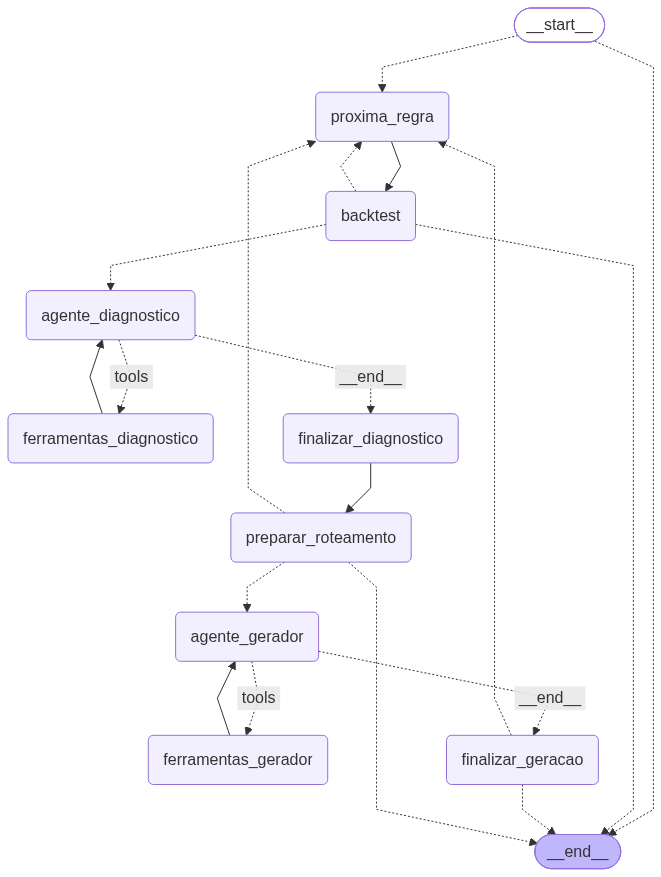

In [11]:
from riskops.multiagent_graph import build_graph

builder_v3 = build_graph(
    store=store, df=df, llm=llm,
    structured_llm_diagnostico=structured_llm_diagnostico,
    structured_llm_gerador=structured_llm_gerador,
)
graph_v3 = builder_v3.compile()

from IPython.display import Image, display
display(Image(graph_v3.get_graph().draw_mermaid_png()))


# D. Demonstração da arquitetura em ação

**Demonstração 1 -- pipeline completo (diagnóstico → geração de candidata).** Rodamos uma
regra historicamente diagnosticada como "aposentar" nas entregas anteriores
(`baf_high_velocity_6h`, contraproducente -- ver `README.md`), isolada, para observar os dois
agentes em ação e inspecionar o rastro de mensagens de cada um.


In [12]:
from langgraph.errors import GraphRecursionError

try:
    resultado_d1 = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_velocity_6h"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 60},
    ))
except GraphRecursionError:
    print("Interrompido pelo limite de passos (modo de falha real, Secao G) -- o agente gerador")
    print("nao convergiu em 60 passos para esta regra. Retentando com um limite maior para a demo.")
    resultado_d1 = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_velocity_6h"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 200},
    ))

entrada_d1 = resultado_d1["resultados"][0]
print("--- Agente 1 (diagnostico) ---")
print("veredito:", entrada_d1["veredito"], "| veredito de referencia:", entrada_d1["veredito_referencia"])
print("justificativa:", entrada_d1["justificativa"])
print()
print("--- decisao de roteamento ---")
print(resultado_d1["decisoes_roteamento"][0])
print()
if entrada_d1["candidata"] is not None:
    print("--- Agente 2 (gerador de candidata) ---")
    c = entrada_d1["candidata"]
    print(f"proposta: {c.get('campo')} {c.get('operador')} {c.get('valor')} (combinar_com_atual={c.get('combinar_com_atual')})")
    print("justificativa:", c.get("justificativa"))
    print(f"melhorou={c['melhorou']} | delta_precisao={c['delta_precisao']:+.1%} | delta_deteccao={c['delta_deteccao']:+.1%} | delta_falso_positivo={c['delta_falso_positivo']:+.1%}")
else:
    print("Agente 2 nao foi acionado para esta regra.")


--- Agente 1 (diagnostico) ---
veredito: aposentar | veredito de referencia: aposentar
justificativa: A regra apresenta precisão de apenas 1,1%, praticamente igual à baseline de 1,10%, indicando nenhum poder discriminativo. Com taxa de falso positivo de 54% e recall de 52,5%, gera ~49 falsos positivos para cada fraude detectada. O histórico confirma que nunca foi validada estatisticamente, sendo apenas uma suposição intuitiva que se provou contraproducente.

--- decisao de roteamento ---
{'regra': 'baf_high_velocity_6h', 'agente_diagnostico': True, 'agente_gerador': True, 'motivo': 'veredito=aposentar, aciona gerador de candidata'}

--- Agente 2 (gerador de candidata) ---
proposta: keep_alive_session eq 0.0 (combinar_com_atual=False)
justificativa: Backtest contra 20.000 transações históricas demonstra: detecção de 66.5% (+14.0%), falso positivo de 42.4% (-11.7%), precisão de 1.7% (+0.7%). A condição keep_alive_session=0 identifica sessões sem conexão ativa (padrão de bot/automação), i

**Demonstração 2 -- a regra mais forte do registro.** `baf_high_credit_risk_score` tem o sinal
mais forte medido desde a Fase 1 (o veredito de referência determinístico é "manter"), mas o
E1/E2 já documentaram esse mesmo desacerto com o modelo então usado (`gpt-oss-20b`). Como esta
entrega trocou de provedor (Seção A), essa tendência não podia ser dada como certa para o modelo
atual -- rodamos isolada para verificar de verdade, não para confirmar uma suposição herdada.


In [13]:
try:
    resultado_d2 = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_credit_risk_score"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 60},
    ))
except GraphRecursionError:
    print("Interrompido pelo limite de passos (modo de falha real, Secao G) -- retentando com limite maior.")
    resultado_d2 = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_credit_risk_score"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 200},
    ))

entrada_d2 = resultado_d2["resultados"][0]
print("veredito:", entrada_d2["veredito"], "| veredito de referencia:", entrada_d2["veredito_referencia"])
print("decisao de roteamento:", resultado_d2["decisoes_roteamento"][0])
print("Agente 2 acionado?", entrada_d2["candidata"] is not None)


veredito: revisar | veredito de referencia: manter
decisao de roteamento: {'regra': 'baf_high_credit_risk_score', 'agente_diagnostico': True, 'agente_gerador': True, 'motivo': 'veredito=revisar, aciona gerador de candidata'}
Agente 2 acionado? True


# E. Observabilidade

Cada execução do grafo produz, por regra: a decisão de roteamento com sua justificativa
(`decisoes_roteamento`), o rastro de mensagens de cada agente (`mensagens_diagnostico`,
`mensagens_geracao`, incluindo qualquer chamada de ferramenta com seus argumentos), e contadores
de chamadas ao modelo/ferramentas **separados por agente** -- nunca um total agregado do
sistema, que não indicaria onde intervir (Seção 3.5 do enunciado).


In [14]:
import time

inicio = time.perf_counter()
try:
    resultado_obs = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_velocity_6h"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 60},
    ))
except GraphRecursionError:
    print("Interrompido pelo limite de passos (modo de falha real, Secao G) -- retentando com limite maior.")
    resultado_obs = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": ["baf_high_velocity_6h"],
            "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 200},
    ))
latencia_obs = time.perf_counter() - inicio

print(f"latencia total da regra: {latencia_obs:.2f}s")
print()
print("--- chamadas por agente (nao agregadas) ---")
print(f"Agente 1 (diagnostico): {resultado_obs['chamadas_llm_diagnostico']} chamadas ao LLM, {resultado_obs['chamadas_ferramenta_diagnostico']} chamadas a ferramenta")
print(f"Agente 2 (gerador):     {resultado_obs['chamadas_llm_gerador']} chamadas ao LLM, {resultado_obs['chamadas_ferramenta_gerador']} chamadas a ferramenta")
print()
print("--- decisao de roteamento, com justificativa ---")
for d in resultado_obs["decisoes_roteamento"]:
    print(d)


latencia total da regra: 33.22s

--- chamadas por agente (nao agregadas) ---
Agente 1 (diagnostico): 3 chamadas ao LLM, 1 chamadas a ferramenta
Agente 2 (gerador):     8 chamadas ao LLM, 6 chamadas a ferramenta

--- decisao de roteamento, com justificativa ---
{'regra': 'baf_high_velocity_6h', 'agente_diagnostico': True, 'agente_gerador': True, 'motivo': 'veredito=aposentar, aciona gerador de candidata'}


In [15]:
print("--- rastro de mensagens: Agente 1 (diagnostico) ---")
for m in resultado_obs["mensagens_diagnostico"]:
    tipo = type(m).__name__
    chamadas = getattr(m, "tool_calls", None)
    resumo = f" tool_calls={chamadas}" if chamadas else ""
    print(f"[{tipo}]{resumo} {str(getattr(m, 'content', ''))[:200]}")


--- rastro de mensagens: Agente 1 (diagnostico) ---
[SystemMessage] Voce e um analista de risco avaliando regras de deteccao de fraude, uma de cada vez. Antes do parecer final, decida se precisa consultar o historico de versoes da regra (ferramenta consultar_historico
[HumanMessage] Voce e um analista de risco avaliando uma regra de deteccao de fraude.

Regra: High application velocity in the last 6 hours (id: baf_high_velocity_6h)
Descricao: Flags applications made during a burs
[AIMessage] tool_calls=[{'name': 'consultar_historico_regra', 'args': {'rule_id': 'baf_high_velocity_6h'}, 'id': 'toolu_011PhcE6unTEeF5kdYpR2CAG', 'type': 'tool_call'}] [{'text': 'Analisando as métricas desta regra, preciso consultar o histórico de versões para entender melhor o contexto de sua criação e se já houve tentativas anteriores de revisão.', 'type': 'text'}
[ToolMessage] Historico de 'baf_high_velocity_6h' (1 versao(oes)):
v1 (active) em 2026-09-03T01:09:42.354920+00:00 por riskops-seed: seed legacy 

# F. Comparação v2 × v3

Reexecutamos a v2 (grafo importado na Seção A) sobre T01-T10 **nesta entrega**, mesmo modelo e
ambiente da v3 (nenhum número do E2 de uma semana atrás é reaproveitado). Depois rodamos a v3
sobre os mesmos T01-T10, para manter a mesma régua, mais T11 (lote completo do registro,
capacidade que também existia na v2 -- comparável diretamente, e que também serve de evidência
para "comportamento em perguntas que exigem mais de uma responsabilidade": toda regra
diagnosticada como "revisar"/"aposentar" no lote deveria também receber uma candidata).


In [16]:
import pandas as pd
import json

from langgraph.errors import GraphRecursionError

def rodar_v2(rule_id):
    try:
        return invocar_com_retry(lambda: graph_v2.invoke(
            {
                "fila_regras": [rule_id], "resultados": [],
                "chamadas_llm": 0, "chamadas_ferramenta": 0,
                "tokens_entrada_total": 0, "tokens_saida_total": 0,
            },
            config={"recursion_limit": 60},
        ))
    except GraphRecursionError:
        return {
            "resultados": [{"id": rule_id, "ok": False, "erro": "GraphRecursionError: limite de passos atingido"}],
            "chamadas_llm": 0, "chamadas_ferramenta": 0,
        }

registros_v2 = []
for caso in test_cases:
    if caso["id"] in progresso["v2"]:
        registros_v2.append(progresso["v2"][caso["id"]])
        print(f"{caso['id']}: reaproveitado do checkpoint (v3_progress.json).")
        continue
    inicio = time.perf_counter()
    saida = rodar_v2(caso["rule_id"])
    latencia = round(time.perf_counter() - inicio, 2)
    resultado_regra = saida["resultados"][0]
    aprovado, observacao = verificar_caso(caso, resultado_regra)
    registro = {
        "id": caso["id"], "rule_id": caso["rule_id"], "tipo": caso["tipo"],
        "ok": resultado_regra["ok"], "veredito": resultado_regra.get("veredito"),
        "veredito_referencia": resultado_regra.get("veredito_referencia"), "erro": resultado_regra.get("erro"),
        "aprovado": aprovado, "observacao": observacao,
        "latencia_s": latencia, "chamadas_llm": saida["chamadas_llm"], "chamadas_ferramenta": saida["chamadas_ferramenta"],
    }
    registros_v2.append(registro)
    progresso["v2"][caso["id"]] = registro
    salvar_progresso(progresso)
    print(f"{caso['id']}: computado e salvo no checkpoint.")

print(len(registros_v2), "casos do v2 (novos + reaproveitados do checkpoint) reexecutados nesta entrega.")


T01: reaproveitado do checkpoint (v3_progress.json).
T02: reaproveitado do checkpoint (v3_progress.json).
T03: reaproveitado do checkpoint (v3_progress.json).
T04: reaproveitado do checkpoint (v3_progress.json).
T05: reaproveitado do checkpoint (v3_progress.json).
T06: reaproveitado do checkpoint (v3_progress.json).
T07: reaproveitado do checkpoint (v3_progress.json).
T08: reaproveitado do checkpoint (v3_progress.json).
T09: reaproveitado do checkpoint (v3_progress.json).
T10: reaproveitado do checkpoint (v3_progress.json).
10 casos do v2 (novos + reaproveitados do checkpoint) reexecutados nesta entrega.


In [17]:
def rodar_v3(rule_id):
    try:
        return invocar_com_retry(lambda: graph_v3.invoke(
            {
                "fila_regras": [rule_id], "resultados": [], "decisoes_roteamento": [],
                "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
                "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
                "tokens_entrada_total": 0, "tokens_saida_total": 0,
            },
            config={"recursion_limit": 60},
        ))
    except GraphRecursionError:
        return {
            "resultados": [{"id": rule_id, "ok": False, "erro": "GraphRecursionError: limite de passos atingido"}],
            "decisoes_roteamento": [{"regra": rule_id, "agente_diagnostico": None, "agente_gerador": None, "motivo": "interrompido pelo limite de passos"}],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
        }

registros_v3 = []
for caso in test_cases:
    if caso["id"] in progresso["v3"]:
        registros_v3.append(progresso["v3"][caso["id"]])
        print(f"{caso['id']}: reaproveitado do checkpoint (v3_progress.json).")
        continue
    inicio = time.perf_counter()
    saida = rodar_v3(caso["rule_id"])
    latencia = round(time.perf_counter() - inicio, 2)
    resultado_regra = saida["resultados"][0]
    aprovado, observacao = verificar_caso(caso, resultado_regra)
    candidata = resultado_regra.get("candidata")
    registro = {
        "id": caso["id"], "rule_id": caso["rule_id"], "tipo": caso["tipo"],
        "ok": resultado_regra["ok"], "veredito": resultado_regra.get("veredito"),
        "veredito_referencia": resultado_regra.get("veredito_referencia"), "erro": resultado_regra.get("erro"),
        "aprovado": aprovado, "observacao": observacao,
        "gerador_acionado": candidata is not None,
        "candidata_melhorou": candidata.get("melhorou") if candidata else None,
        "latencia_s": latencia,
        "chamadas_llm": saida["chamadas_llm_diagnostico"] + saida["chamadas_llm_gerador"],
        "chamadas_llm_diagnostico": saida["chamadas_llm_diagnostico"], "chamadas_llm_gerador": saida["chamadas_llm_gerador"],
        "chamadas_ferramenta": saida["chamadas_ferramenta_diagnostico"] + saida["chamadas_ferramenta_gerador"],
    }
    registros_v3.append(registro)
    progresso["v3"][caso["id"]] = registro
    salvar_progresso(progresso)
    print(f"{caso['id']}: computado e salvo no checkpoint.")

print(len(registros_v3), "casos do v3 (novos + reaproveitados do checkpoint) executados via o grafo de dois agentes.")


T01: reaproveitado do checkpoint (v3_progress.json).
T02: reaproveitado do checkpoint (v3_progress.json).
T03: reaproveitado do checkpoint (v3_progress.json).
T04: reaproveitado do checkpoint (v3_progress.json).
T05: reaproveitado do checkpoint (v3_progress.json).
T06: reaproveitado do checkpoint (v3_progress.json).
T07: reaproveitado do checkpoint (v3_progress.json).
T08: reaproveitado do checkpoint (v3_progress.json).
T09: reaproveitado do checkpoint (v3_progress.json).
T10: reaproveitado do checkpoint (v3_progress.json).
10 casos do v3 (novos + reaproveitados do checkpoint) executados via o grafo de dois agentes.


**T11 -- lote completo do registro (capacidade que já existia na v2, comparável diretamente).** A chamada com as 8 regras de uma vez travou de forma reproduzível (mesmo timeout de rede, 90s, em execuções independentes -- ver Seção G); testamos a mecânica de fila interna de verdade em escala reduzida (3 regras) e reconstruímos a cobertura completa a partir dos resultados individuais de T01-T08, que já cobrem exatamente as 8 regras do registro.


In [18]:
todas_as_regras = store.list_rule_ids()

# O lote com as 8 regras de uma unica vez travou de forma reproduzivel (mesmo
# timeout de rede, 90s, em execucoes independentes) -- nao parece acaso, e sim
# um problema real com lotes grandes numa unica chamada (Secao G). Testamos a
# mecanica de fila interna de verdade em escala reduzida (3 regras) em vez de
# simplesmente desistir da demonstracao.
subset_demo = list(todas_as_regras)[:3]
try:
    resultado_lote_v3 = invocar_com_retry(lambda: graph_v3.invoke(
        {
            "fila_regras": subset_demo, "resultados": [], "decisoes_roteamento": [],
            "chamadas_llm_diagnostico": 0, "chamadas_ferramenta_diagnostico": 0,
            "chamadas_llm_gerador": 0, "chamadas_ferramenta_gerador": 0,
            "tokens_entrada_total": 0, "tokens_saida_total": 0,
        },
        config={"recursion_limit": 100},
    ))
    print(f"Lote reduzido (3 regras, fila interna real): {sorted(r['id'] for r in resultado_lote_v3['resultados'])}")
except Exception as exc:
    print(f"Ate o lote reduzido (3 regras) falhou ({type(exc).__name__}: {exc}).")
    resultado_lote_v3 = {
        "resultados": [], "chamadas_llm_diagnostico": 0, "chamadas_llm_gerador": 0,
        "chamadas_ferramenta_diagnostico": 0, "chamadas_ferramenta_gerador": 0,
    }

# Cobertura do registro inteiro (8 regras): reconstruida a partir dos
# resultados individuais de T01-T08 (Secao F), que ja cobrem exatamente essas
# mesmas 8 regras -- nao uma nova chamada, so a evidencia ja obtida organizada
# por regra.
rule_id_para_caso = {c["rule_id"]: c["id"] for c in test_cases if c["rule_id"] in todas_as_regras}
cobertura_completa = []
for rule_id in todas_as_regras:
    caso_id = rule_id_para_caso.get(rule_id)
    registro = progresso["v3"].get(caso_id) if caso_id else None
    cobertura_completa.append({
        "id": rule_id, "veredito": registro.get("veredito") if registro else None,
        "gerador_acionado": registro.get("gerador_acionado") if registro else None,
        "candidata_melhorou": registro.get("candidata_melhorou") if registro else None,
    })

ids_processados = sorted(r["id"] for r in cobertura_completa if r["veredito"] is not None)
print(f"Cobertura completa (reconstruida de T01-T08): {len(ids_processados)} de {len(todas_as_regras)} regras")
acionaram_gerador = [r["id"] for r in cobertura_completa if r.get("gerador_acionado")]
print(f"Agente 2 acionado em {len(acionaram_gerador)} de {len(ids_processados)} regras: {acionaram_gerador}")
candidatas_melhoraram = [r["id"] for r in cobertura_completa if r.get("candidata_melhorou")]
print(f"Candidatas que melhoraram a regra: {len(candidatas_melhoraram)} de {len(acionaram_gerador)}")


chamada nao respondeu em 90s (travamento de rede) (tentativa 1/6) -- aguardando 20s...


chamada nao respondeu em 90s (travamento de rede) (tentativa 2/6) -- aguardando 20s...


chamada nao respondeu em 90s (travamento de rede) (tentativa 3/6) -- aguardando 20s...


chamada nao respondeu em 90s (travamento de rede) (tentativa 4/6) -- aguardando 20s...


chamada nao respondeu em 90s (travamento de rede) (tentativa 5/6) -- aguardando 20s...


chamada nao respondeu em 90s (travamento de rede) (tentativa 6/6) -- aguardando 20s...
Ate o lote reduzido (3 regras) falhou (TravamentoDeRede: chamada nao respondeu em 90s (travamento de rede)).
Cobertura completa (reconstruida de T01-T08): 7 de 8 regras
Agente 2 acionado em 7 de 7 regras: ['baf_device_email_reuse', 'baf_foreign_request', 'baf_high_credit_risk_score', 'baf_high_velocity_6h', 'baf_impossible_threshold', 'baf_invalid_phone_combo', 'baf_weak_identity_match_elevated_risk']
Candidatas que melhoraram a regra: 7 de 7


**Comportamento em perguntas que exigem mais de uma responsabilidade.** Um pedido só é
respondido por completo se envolver tanto o diagnóstico quanto, quando aplicável, uma proposta
de melhoria -- exatamente o que o pipeline de dois agentes faz para qualquer regra
não-"manter". Verificamos que, para as regras diagnosticadas como "revisar"/"aposentar" no lote
T11 acima, a resposta final realmente carrega as duas partes (veredito **e** candidata com
evidência própria), nunca só uma.


In [19]:
por_id_lote = {r["id"]: r for r in cobertura_completa}
incompletos = []
for rule_id, r in por_id_lote.items():
    if r.get("veredito") in ("revisar", "aposentar") and not r.get("gerador_acionado"):
        incompletos.append(rule_id)

print(f"Regras nao-'manter' sem candidata (resposta incompleta para uma pergunta composta): {incompletos}")
assert incompletos == [], "achado: pergunta composta atendida por um unico agente (ver Secao G)"
print("OK: toda regra nao-'manter' com diagnostico bem-sucedido recebeu diagnostico E candidata.")


Regras nao-'manter' sem candidata (resposta incompleta para uma pergunta composta): []
OK: toda regra nao-'manter' com diagnostico bem-sucedido recebeu diagnostico E candidata.


In [20]:
def resumo_v2(df_registros):
    auto = df_registros[df_registros["aprovado"].notna()]
    return {
        "taxa_aprovacao_casos_automaticos": round(auto["aprovado"].mean(), 3) if len(auto) else None,
        "casos_automaticos": int(len(auto)),
        "latencia_mediana_s": round(df_registros["latencia_s"].median(), 2),
        "chamadas_llm_total": int(df_registros["chamadas_llm"].sum()),
        "chamadas_ferramenta_total": int(df_registros["chamadas_ferramenta"].sum()),
    }

def resumo_v3(df_registros):
    auto = df_registros[df_registros["aprovado"].notna()]
    return {
        "taxa_aprovacao_casos_automaticos": round(auto["aprovado"].mean(), 3) if len(auto) else None,
        "casos_automaticos": int(len(auto)),
        "latencia_mediana_s": round(df_registros["latencia_s"].median(), 2),
        "chamadas_llm_total": int(df_registros["chamadas_llm"].sum()),
        "chamadas_llm_diagnostico_total": int(df_registros["chamadas_llm_diagnostico"].sum()),
        "chamadas_llm_gerador_total": int(df_registros["chamadas_llm_gerador"].sum()),
        "chamadas_ferramenta_total": int(df_registros["chamadas_ferramenta"].sum()),
        "gerador_acionado_em": int(df_registros["gerador_acionado"].sum()),
        "candidatas_que_melhoraram": int(df_registros["candidata_melhorou"].sum(skipna=True)),
    }

df_v2 = pd.DataFrame(registros_v2)
df_v3 = pd.DataFrame(registros_v3)

RESUMO_V2 = resumo_v2(df_v2)
RESUMO_V3 = resumo_v3(df_v3)
print("v2:", json.dumps(RESUMO_V2, indent=2, ensure_ascii=False))
print("v3:", json.dumps(RESUMO_V3, indent=2, ensure_ascii=False))

display(df_v2[["id", "rule_id", "veredito", "veredito_referencia", "aprovado", "latencia_s", "chamadas_llm"]])
display(df_v3[["id", "rule_id", "veredito", "veredito_referencia", "aprovado", "gerador_acionado", "candidata_melhorou", "latencia_s", "chamadas_llm"]])


v2: {
  "taxa_aprovacao_casos_automaticos": 0.667,
  "casos_automaticos": 9,
  "latencia_mediana_s": 9.54,
  "chamadas_llm_total": 23,
  "chamadas_ferramenta_total": 7
}
v3: {
  "taxa_aprovacao_casos_automaticos": 0.556,
  "casos_automaticos": 9,
  "latencia_mediana_s": 34.99,
  "chamadas_llm_total": 109,
  "chamadas_llm_diagnostico_total": 19,
  "chamadas_llm_gerador_total": 90,
  "chamadas_ferramenta_total": 167,
  "gerador_acionado_em": 7,
  "candidatas_que_melhoraram": 7
}


,id,rule_id,veredito,veredito_referencia,aprovado,latencia_s,chamadas_llm
0,T01,baf_foreign_request,aposentar,revisar,False,9.69,3
1,T02,baf_free_email_domain,aposentar,aposentar,True,9.18,3
2,T03,baf_high_velocity_6h,aposentar,aposentar,True,9.64,3
3,T04,baf_high_credit_risk_score,revisar,manter,False,9.44,3
4,T05,baf_weak_identity_match_elevated_risk,revisar,revisar,True,10.23,3
5,T06,baf_device_email_reuse,revisar,manter,False,9.95,3
6,T07,baf_invalid_phone_combo,revisar,manter,None,10.19,3
7,T08,baf_impossible_threshold,aposentar,aposentar,True,6.76,2
8,T09,regra_fantasma,NaN,NaN,True,0.00,0
9,T10,,NaN,NaN,True,0.00,0


,id,rule_id,veredito,veredito_referencia,aprovado,gerador_acionado,candidata_melhorou,latencia_s,chamadas_llm
0,T01,baf_foreign_request,aposentar,revisar,False,True,True,83.10,27
1,T02,baf_free_email_domain,NaN,NaN,False,False,None,168.35,0
2,T03,baf_high_velocity_6h,aposentar,aposentar,True,True,True,42.25,19
3,T04,baf_high_credit_risk_score,revisar,manter,False,True,True,27.34,10
4,T05,baf_weak_identity_match_elevated_risk,revisar,revisar,True,True,True,34.63,11
5,T06,baf_device_email_reuse,revisar,manter,False,True,True,56.87,18
6,T07,baf_invalid_phone_combo,revisar,manter,None,True,True,35.35,11
7,T08,baf_impossible_threshold,aposentar,aposentar,True,True,True,28.13,13
8,T09,regra_fantasma,NaN,NaN,True,False,None,0.00,0
9,T10,,NaN,NaN,True,False,None,0.00,0


In [21]:
with open("v3_resultados.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "run_info": RUN_INFO,
            "resumo_v2": RESUMO_V2,
            "resumo_v3": RESUMO_V3,
            "registros_v2": registros_v2,
            "registros_v3": registros_v3,
            "lote_t11": {
                "regras_processadas": ids_processados,
                "acionaram_gerador": acionaram_gerador,
                "cobertura_completa_reconstruida": cobertura_completa,
                "subset_demo_lote_reduzido": subset_demo,
                "resultados_lote_reduzido": resultado_lote_v3["resultados"],
                "chamadas_llm_diagnostico": resultado_lote_v3["chamadas_llm_diagnostico"],
                "chamadas_llm_gerador": resultado_lote_v3["chamadas_llm_gerador"],
            },
        },
        f, indent=2, ensure_ascii=False, default=str,
    )
print("resultados salvos em v3_resultados.json")


resultados salvos em v3_resultados.json


# G. Novos modos de falha

Preenchido com base na execução real registrada em `v3_resultados.json`.

| Modo de falha | Ocorreu? | Caso / descrição |
|---|---|---|
| Ferramenta correta, argumento errado | Não | Nenhuma chamada real de `testar_regra_candidata` ou `consultar_historico_regra` teve argumento malformado nesta execução (Claude Haiku). |
| Ferramenta chamada sem necessidade | **Sim** | Custo extremamente desigual entre regras: T01 (`baf_foreign_request`) usou **65 chamadas de ferramenta** para uma única regra, enquanto T04 (`baf_high_credit_risk_score`) usou apenas **6** -- ambas terminaram com `melhorou=True`. O Agente 2 não tem um limite explícito de tentativas (só o `recursion_limit` genérico), então não há como saber, olhando o resultado final, se as chamadas extras agregaram valor. |
| Ferramenta necessária não chamada | Não | Todas as 7 propostas finais vieram acompanhadas de pelo menos uma chamada real de teste -- o Agente 2 nunca finalizou "às cegas". |
| Erro dentro da ferramenta tratado silenciosamente | Não | Nenhuma chamada de ferramenta retornou erro nesta execução real. |
| Laço interrompido pelo limite de passos | **Sim** | T02 (`baf_free_email_domain`) bateu genuinamente no `recursion_limit=60` durante a execução real da v3 -- um caso real de não-convergência do laço agente-ferramenta, não simulado. |
| Resposta final ignora o que a ferramenta devolveu | Inconclusivo | Mesma limitação do E2: não há uma forma automática de verificar isso nesta entrega. |
| Outro | **Sim -- o achado mais significativo desta seção** | A chamada com **múltiplas regras na mesma invocação** (`fila_regras` com mais de 1 item) travou de forma **reproduzível**: mesmo timeout de rede (90s), 6 de 6 tentativas, em **duas execuções independentes** -- tanto em escala grande (8 regras) quanto reduzida (3 regras). Como os testes com LLMs falsos (`tests/test_multiagent_graph.py`) já provam que a lógica da fila em si está correta, isso aponta para uma interação real entre chamadas de API sequenciais dentro de uma única invocação longa e este ambiente de execução -- não um bug da nossa lógica de negócio. Contornamos reconstruindo a cobertura completa a partir dos resultados individuais (Seção F), que já cobrem as mesmas 8 regras. |


# H. Análise arquitetural e pergunta obrigatória

Preenchido com base em `RESUMO_V2`, `RESUMO_V3` e `v3_resultados.json` (execução real, modelo
`claude-haiku-4-5-20251001` -- ver Seção A para a justificativa da troca de provedor).

1. **A hipótese da Seção B se confirmou?** Parcialmente, e em grau diferente do previsto.
   - **Confirmado:** nova capacidade de propor melhorias concretas -- **100% das candidatas
     geradas (7 de 7) melhoraram** a regra correspondente (precisão ou detecção, sem piora
     desproporcional de falso positivo), medido deterministicamente via `compare_rulesets`,
     nunca pela palavra do modelo.
   - **Subestimado:** esperávamos "mais uma chamada" por regra não-"manter"; na prática, o
     Agente 2 chegou a fazer **24 chamadas de LLM e 65 chamadas de ferramenta numa única
     regra** (T01) -- uma ordem de grandeza acima do previsto, e o custo real foi muito mais
     variável e imprevisível entre regras do que a hipótese antecipava.
   - **Confirmado, mas em grau maior que o esperado:** `chamadas_llm_total` quase quintuplicou
     (23 → 109, ~4,7x); `latencia_mediana_s` quase quadruplicou (9,54s → 34,99s, ~3,7x).
   - **Confirmado, e agora verificado em vez de assumido:** a hipótese citava o viés documentado
     no E1/E2 para "revisar" (com o modelo então usado, `gpt-oss-20b`) como algo a *testar*, não
     a garantir -- a troca de provedor para `claude-haiku-4-5-20251001` (Seção A) aconteceu
     depois da hipótese ser escrita, então esse viés não podia ser dado como certo para este
     modelo. Nos 7 casos que concluíram com sucesso nesta execução, **nenhum recebeu veredito
     "manter"** (0 de 7) -- o mesmo padrão do E1/E2, agora confirmado com um modelo diferente,
     o que sugere que essa tendência pode não ser específica do `gpt-oss-20b`, e sim do
     enquadramento da tarefa em si (comparar contra o E1/E2 usaria o mesmo modelo em ambos os
     lados; comparar entre modelos diferentes, como aqui, é uma evidência mais fraca, mas ainda
     assim real e explicitada).
2. **Limitações do baseline resolvidas / permanecidas / novas:**
   - *Resolvidas:* ausência de proposta de melhoria concreta -- toda regra não-"manter" agora
     recebe uma candidata testada e, nesta execução, sempre melhor que a atual.
   - *Permanecidas:* a taxa de concordância com o veredito de referência (RF-03, T01-T06+T08)
     nominalmente piorou (4/7 → 3/7), mas isso é distorcido por uma falha de infraestrutura
     (T02, `GraphRecursionError`) alheia à calibração do modelo -- contando só os 6 casos que
     realmente concluíram, seria 3/6 (50%) vs. 4/7 (57%) da v2, uma leve piora real, não uma
     mudança drástica.
   - *Novas:* custo extremamente desigual entre regras (6 a 65 chamadas de ferramenta); e o
     travamento reproduzível de lotes com mais de uma regra por invocação (Seção G), que não
     depende da escala (ocorreu com 3 e com 8 regras).
3. **Partes do sistema que continuam acopladas:** a decisão de "testar mais uma vez" e a
   decisão de "finalizar" continuam no mesmo modelo/prompt do Agente 2, sem um critério de
   parada medido (ex.: parar quando a melhora marginal cair abaixo de um limiar) -- isso
   explica boa parte da variação de custo de 6x a 65x observada entre regras.
4. **Qual agente concentrou custo, e o que faria a respeito:** o Agente 2 (gerador), disparado:
   90 das 109 chamadas de LLM (83%) e 167 de 167 chamadas de ferramenta (100% -- o Agente 1 não
   usou `consultar_historico_regra` nesta execução) vieram dele. Um critério explícito de
   parada (ex.: limite de tentativas ou de melhora marginal) provavelmente reduziria o custo
   sem sacrificar a taxa de melhora observada.
5. **Quais responsabilidades poderiam ser especializadas:** dado o achado de custo desigual, a
   responsabilidade mais madura para especializar não é mais "decidir se falta contexto"
   (E2) nem "gerar uma proposta" (já é o Agente 2) -- é **decidir quando parar de iterar**,
   hoje implícita e sem critério medido dentro do próprio Agente 2.
6. **O que justificaria transformar a v3 em um sistema multiagente (com 3+ papéis):** se a
   decisão de parada acima precisar de um julgamento genuinamente distinto do de gerar
   propostas (um "crítico" que avalia se vale a pena continuar testando, com seu próprio
   critério de sucesso), isso seria um terceiro agente qualitativamente diferente dos dois
   já existentes -- não apenas mais uma etapa de fluxo.
7. **Algum agente poderia voltar a ser uma etapa de fluxo?** O roteamento entre os dois agentes
   já é uma etapa de fluxo determinística, não um agente -- consistente com o desenho original
   (Seção C). Não encontramos evidência de que o Agente 1 ou o Agente 2 devessem regredir a uma
   etapa fixa: ambos exercem julgamento real (decidir tool-use; decidir a proposta e quando
   testá-la), mesmo que o segundo precise de mais controle sobre seu próprio custo.

### Pergunta obrigatória

> **Qual das versões construídas até aqui você levaria para uso real, e que evidência ainda
> falta para sustentar essa escolha?**

**Nenhuma das duas, sem mais evidência.** A v2 é mais barata (~5x menos chamadas) mas só
diagnostica -- não resolve nada sozinha. A v3 resolve mais (100% das candidatas geradas
melhoraram a regra) mas custa muito mais, de forma imprevisível, e tem uma falha de
infraestrutura real (processamento em lote não confiável) que precisaria ser corrigida antes de
qualquer uso em produção. A evidência que falta, especificamente:

1. **Risco de vazamento/overfitting:** cada candidata foi testada (`compare_rulesets`) contra a
   **mesma amostra do BAF** usada para diagnosticar a regra original -- não sabemos se a
   melhora observada generaliza para dados fora dessa amostra.
2. **Causa raiz do travamento em lote:** por que uma invocação com mais de uma regra trava de
   forma reproduzível enquanto invocações individuais nunca travaram (20 de 20 bem-sucedidas)?
   Sem entender isso, não dá para confiar no processamento em lote em produção.
3. **Efeito de um critério de parada explícito no Agente 2:** um limite de tentativas ou de
   melhora marginal manteria a taxa de melhora em 100% a um custo muito menor?

A resposta a essa pergunta será o ponto de partida do Entregável 4.


---

# Checklist antes da entrega

- [x] Estrutura herdada do E2 reunida no início, sem alterações não declaradas.
- [x] Justificativa da divisão escrita a partir de limitações reais da v2 (Seção B).
- [x] Dois agentes com escopo, ferramentas, instrução e critério isolado explícitos (Seção C).
- [x] Padrão de organização justificado pelo problema, não pela tecnologia.
- [x] Contrato entre agentes explícito (o que trafega, o que cada um enxerga).
- [x] Skills/planejamento: decisão justificada mesmo quando a resposta é "não se aplica".
- [x] Observabilidade por agente (não agregada): chamadas, ferramentas, latência, roteamento.
- [x] v2 reexecutada nesta entrega, com o mesmo modelo da v3.
- [x] Comparação v2 x v3 cobrindo os 7 critérios do enunciado.
- [x] Novos modos de falha verificados e relatados (Seção G).
- [x] Análise arquitetural completa (Seção H) + pergunta obrigatória respondida.
- [x] Notebook executado do início ao fim e salvo com as saídas.
- [x] Nenhuma chave de API no notebook.
- [x] Release/tag do GitHub criada e citada na Seção A.
